# EV Delivery and Production Analysis

The electric vehicle industry has experienced remarkable growth over the past decade. This dataset contains quarterly production and delivery data from 2015 to 2025, offering insights into how EV manufacturers have expanded their operations to meet rising demand.

In this project, we will analyze production and delivery trends, explore relationships between key features, and build predictive models to estimate vehicle deliveries. We will also compare the performance of Linear Regression, Ridge Regression (L2), and Lasso Regression (L1) models to identify the most effective approach.


## IMPORT LIBRARIES

In [47]:
# Numerical & Data Handling
import pandas as pd
import numpy as np

# Warnings
import warnings
warnings.filterwarnings('ignore')\

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score

from sklearn.pipeline import make_pipeline

## LOAD DATASET

In [48]:
ev_data = pd.read_csv('ev_data.csv')
print("Rows:", ev_data.shape[0])
print("Columns:", ev_data.shape[1])

ev_data.head()

Rows: 2640
Columns: 12


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## Dataset Exploration

In [49]:
ev_data.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [50]:
ev_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [51]:
ev_data.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [52]:
ev_data.duplicated().sum()

np.int64(0)

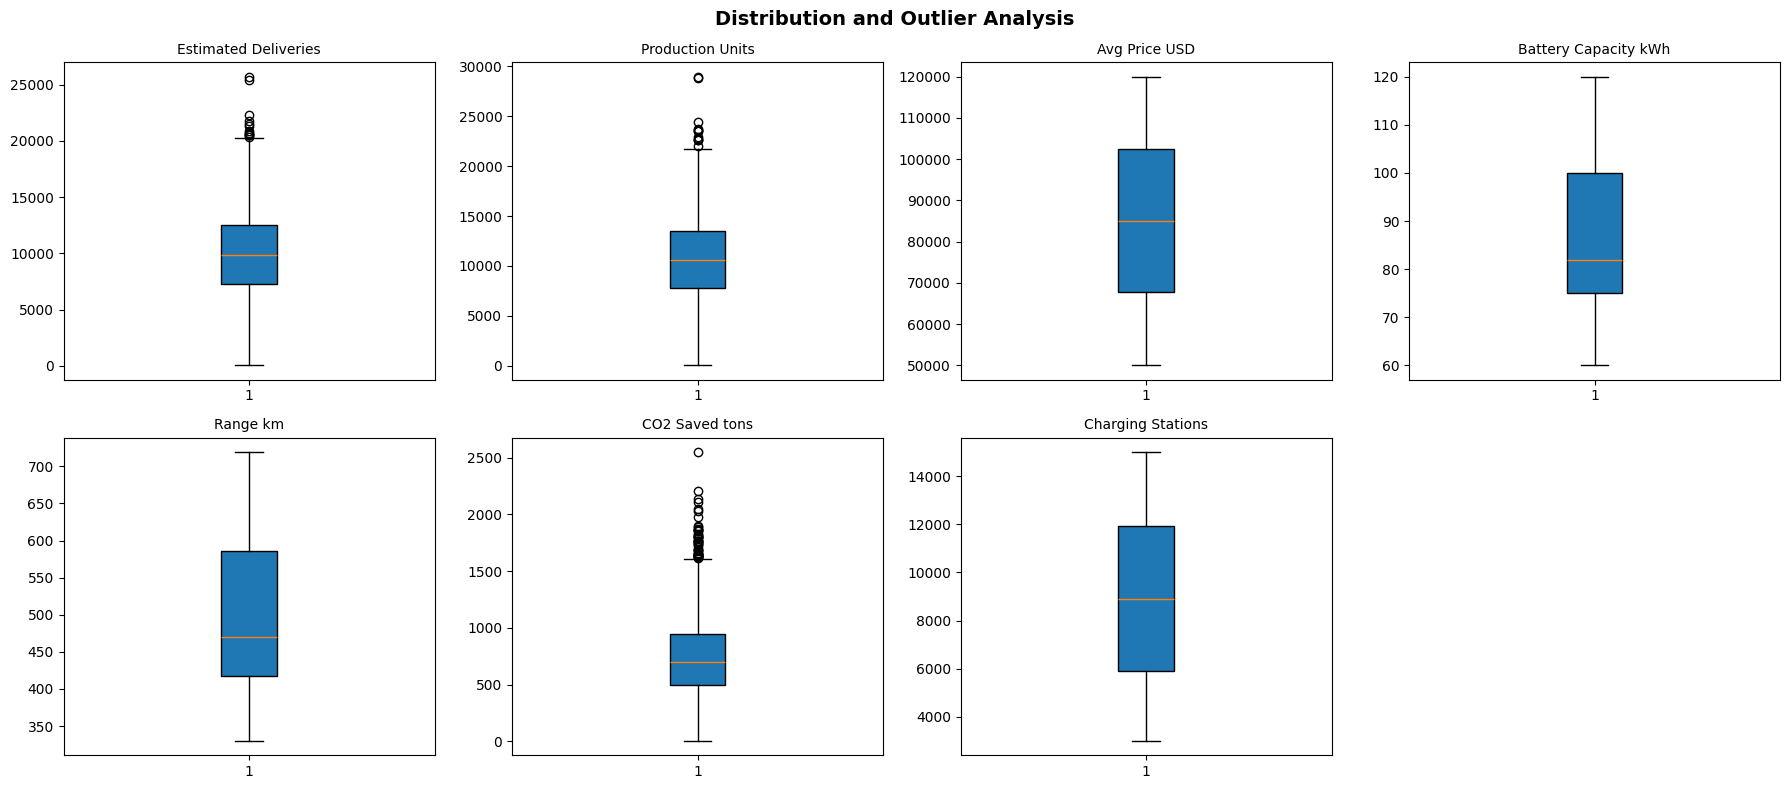

In [53]:
num_features = ['Estimated_Deliveries','Production_Units','Avg_Price_USD','Battery_Capacity_kWh','Range_km','CO2_Saved_tons','Charging_Stations']
fig, ax = plt.subplots(
    nrows=2,
    ncols=4,
    figsize=(18, 8)
)
ax = ax.ravel()
for idx, feature in enumerate(num_features):
    ax[idx].boxplot(
        ev_data[feature],
        patch_artist=True
    )
    ax[idx].set_title(
        feature.replace('_', ' '),
        fontsize=10
    )
ax[7].set_visible(False)
fig.suptitle(
    'Distribution and Outlier Analysis',
    fontsize=14,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

In [54]:
print("IQR-Based Outlier Summary\n")
for feature in num_features:
    first_quartile = ev_data[feature].quantile(0.25)
    third_quartile = ev_data[feature].quantile(0.75)
    iqr_value = third_quartile - first_quartile
    lower_limit = first_quartile - (1.5 * iqr_value)
    upper_limit = third_quartile + (1.5 * iqr_value)
    outlier_count = (
        (ev_data[feature] < lower_limit) |
        (ev_data[feature] > upper_limit)
    ).sum()
    print(f"{feature:<25} : {outlier_count}")

IQR-Based Outlier Summary

Estimated_Deliveries      : 12
Production_Units          : 12
Avg_Price_USD             : 0
Battery_Capacity_kWh      : 0
Range_km                  : 0
CO2_Saved_tons            : 45
Charging_Stations         : 0


## Correlation Heatmap

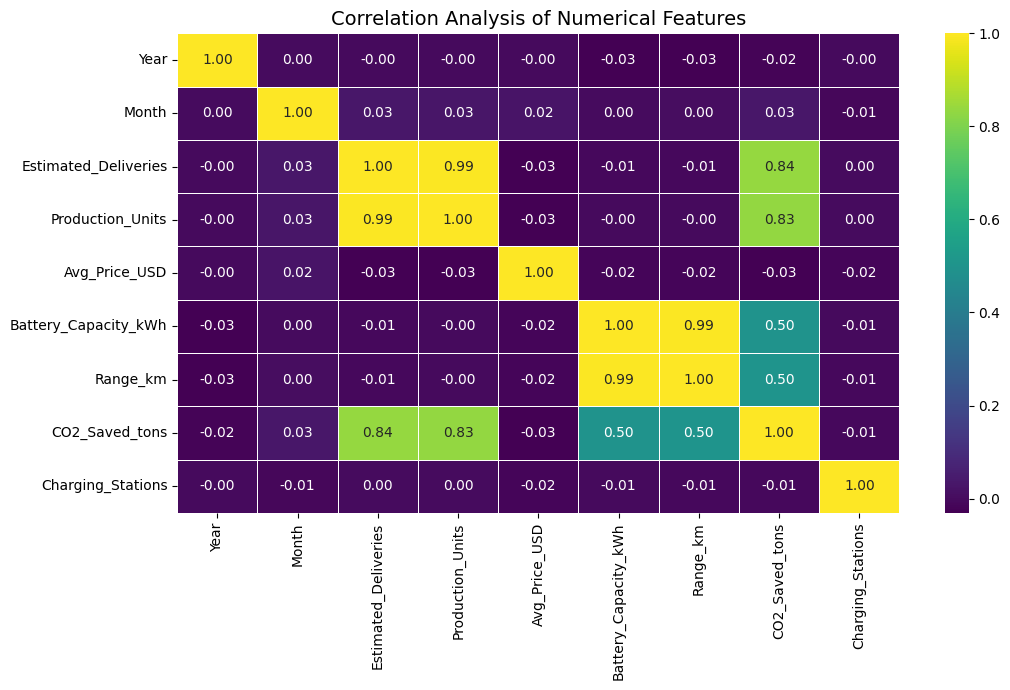

In [55]:
corr_matrix = ev_data.select_dtypes(
    include='number'
).corr()
plt.figure(
    figsize=(11, 7)
)
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    linewidths=0.5
)
plt.title(
    "Correlation Analysis of Numerical Features",
    fontsize=14
)

plt.tight_layout()
plt.show()

### Key Observation

The heatmap suggests that Production Units, Charging Stations, and CO₂ Saved are positively related to Estimated Deliveries. These features may be useful for prediction models.

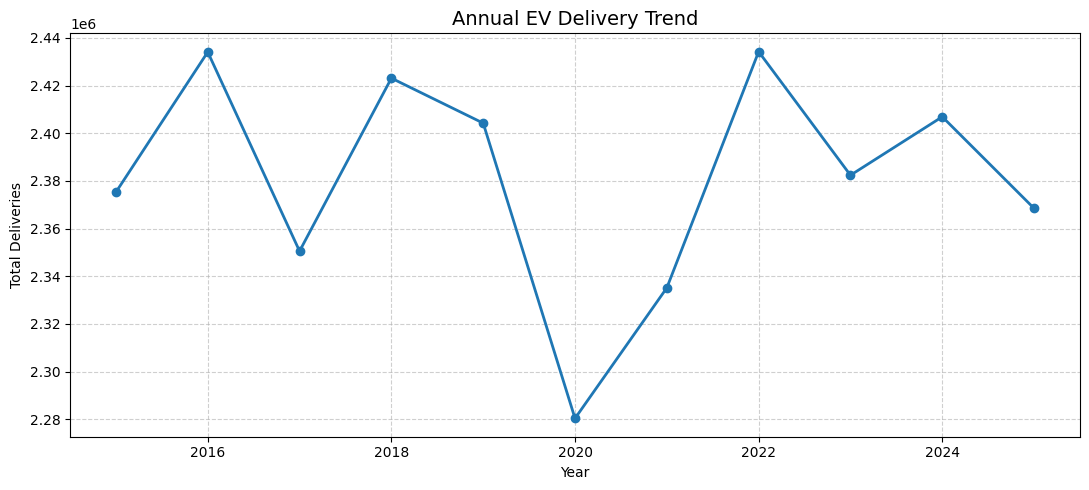

In [56]:
annual_deliveries = (
    ev_data.groupby('Year')
           ['Estimated_Deliveries']
           .sum()
)
plt.figure(figsize=(11, 5))
plt.plot(
    annual_deliveries.index,
    annual_deliveries.values,
    marker='o',
    linewidth=2
)
plt.title(
    'Annual EV Delivery Trend',
    fontsize=14
)
plt.xlabel('Year')
plt.ylabel('Total Deliveries')
plt.grid(
    linestyle='--',
    alpha=0.6
)
plt.tight_layout()
plt.show()

### Key Observation

Vehicle deliveries increased consistently over the years, indicating strong market demand and business expansion. The overall trend highlights significant growth in EV adoption.

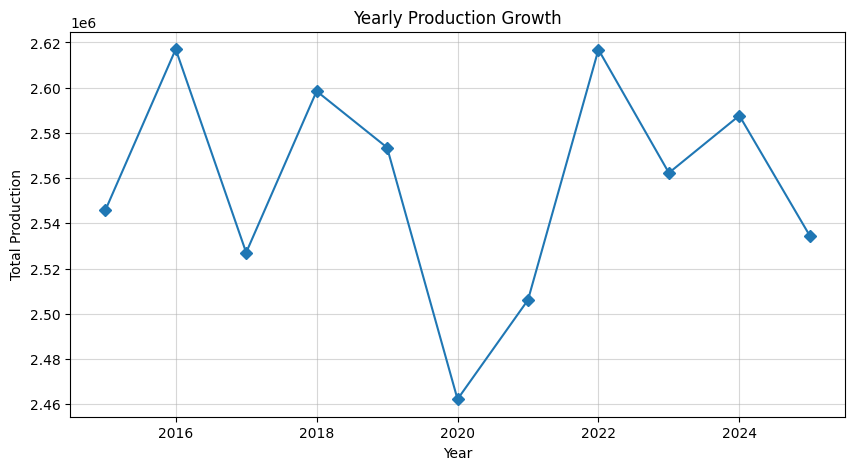

In [57]:
production_summary = ev_data.groupby('Year')['Production_Units'].sum()
plt.figure(figsize=(10, 5))
plt.plot(
    production_summary.index,
    production_summary.values,
    marker='D'
)
plt.title('Yearly Production Growth')
plt.xlabel('Year')
plt.ylabel('Total Production')
plt.grid(alpha=0.5)
plt.show()

### Key Observation

Production units increased steadily over the years, reflecting the company's expanding manufacturing capacity and growing market demand.

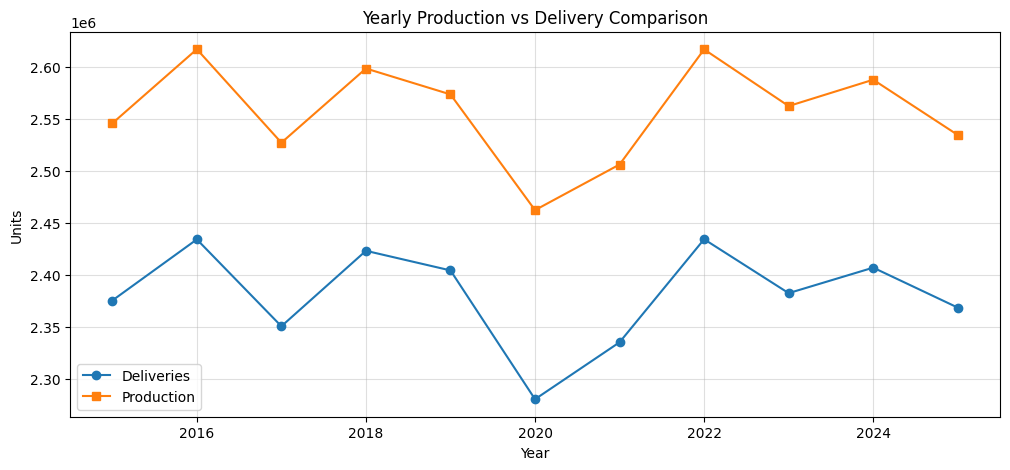

In [58]:
annual_metrics = ev_data.groupby('Year')[['Estimated_Deliveries', 'Production_Units']].sum()
plt.figure(figsize=(12, 5))
plt.plot(
    annual_metrics.index,
    annual_metrics['Estimated_Deliveries'],
    marker='o',
    label='Deliveries'
)
plt.plot(
    annual_metrics.index,
    annual_metrics['Production_Units'],
    marker='s',
    label='Production'
)
plt.title('Yearly Production vs Delivery Comparison')
plt.xlabel('Year')
plt.ylabel('Units')
plt.legend()
plt.grid(alpha=0.4)
plt.show()

### Key Observation

Production and deliveries follow a similar upward trend over the years. The close movement between the two metrics indicates that increasing production capacity supports higher vehicle deliveries.

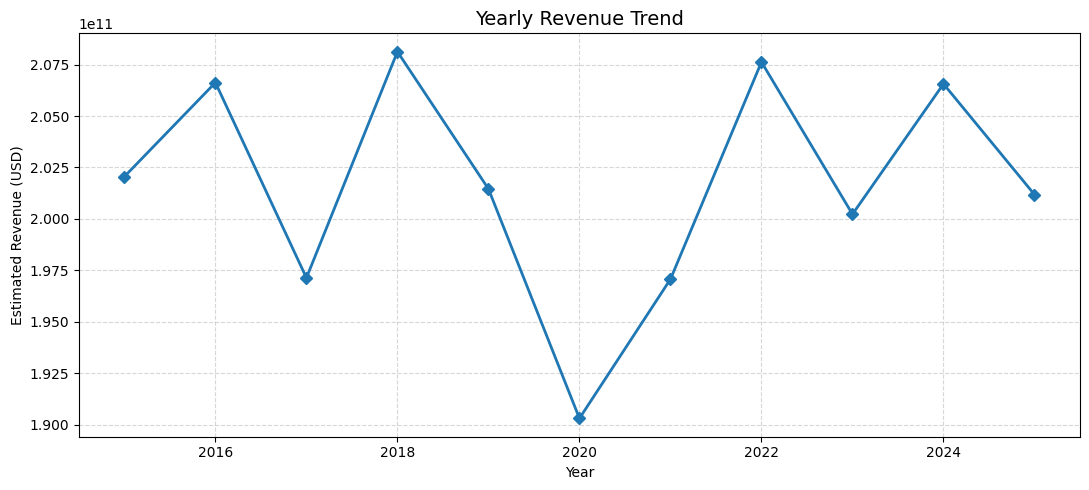

In [59]:
ev_data['Estimated_Revenue'] = (
    ev_data['Estimated_Deliveries']
    * ev_data['Avg_Price_USD']
)
annual_revenue = (
    ev_data.groupby('Year')
           ['Estimated_Revenue']
           .sum()
)
plt.figure(figsize=(11, 5))
plt.plot(
    annual_revenue.index,
    annual_revenue.values,
    marker='D',
    linewidth=2
)
plt.title(
    'Yearly Revenue Trend',
    fontsize=14
)
plt.xlabel('Year')
plt.ylabel('Estimated Revenue (USD)')
plt.grid(
    linestyle='--',
    alpha=0.5
)
plt.tight_layout()
plt.show()

### Key Observation

Revenue shows a strong upward trend, reflecting sustained growth in vehicle deliveries over time.

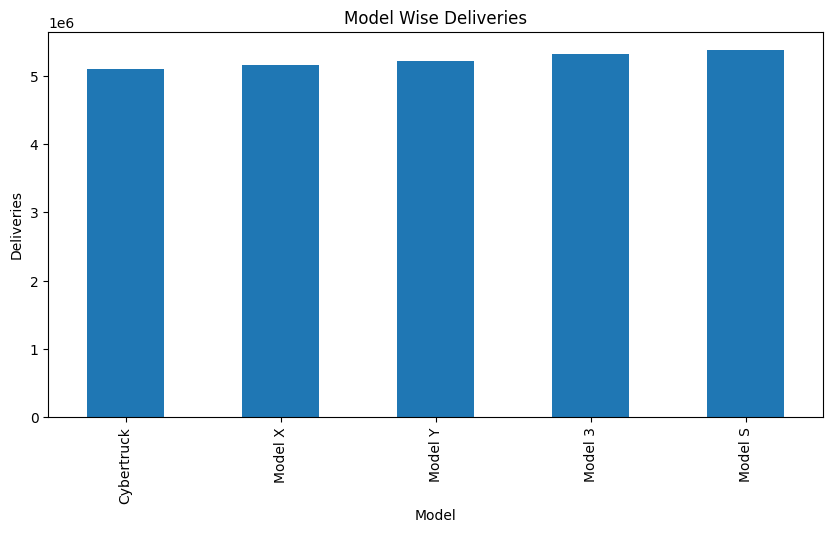

In [60]:
plt.figure(figsize=(10,5))
model_sales = ev_data.groupby('Model')['Estimated_Deliveries'].sum()
model_sales.sort_values().plot(
    kind='bar'
)
plt.title('Model Wise Deliveries')
plt.ylabel('Deliveries')
plt.show()

### Key Observation

Customer demand varies across EV models. The top-selling model contributes the largest share of total deliveries and appears to be the most popular vehicle among consumers.

Model S generated the highest deliveries, highlighting its strong market acceptance.

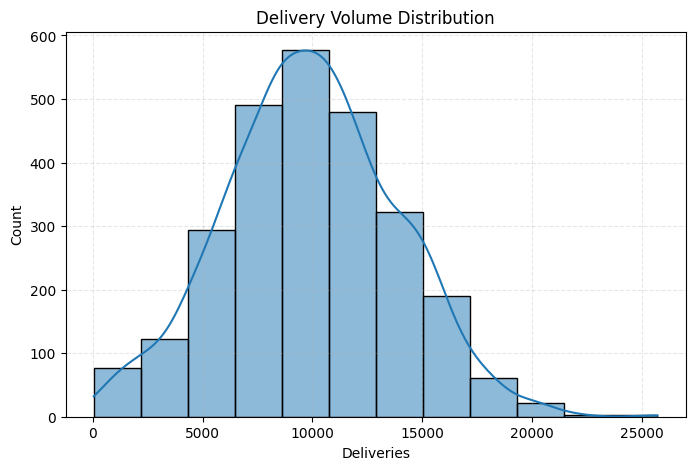

In [61]:
plt.figure(figsize=(8, 5))
sns.histplot(
    ev_data['Estimated_Deliveries'],
    kde=True,
    bins=12
)
plt.title('Delivery Volume Distribution')
plt.xlabel('Deliveries')
plt.ylabel('Count')
plt.grid(
    alpha=0.3,
    linestyle='--'
)
plt.show()

### Key Observation

Most delivery values are clustered around the middle range, with a few higher values reflecting periods of rapid growth.

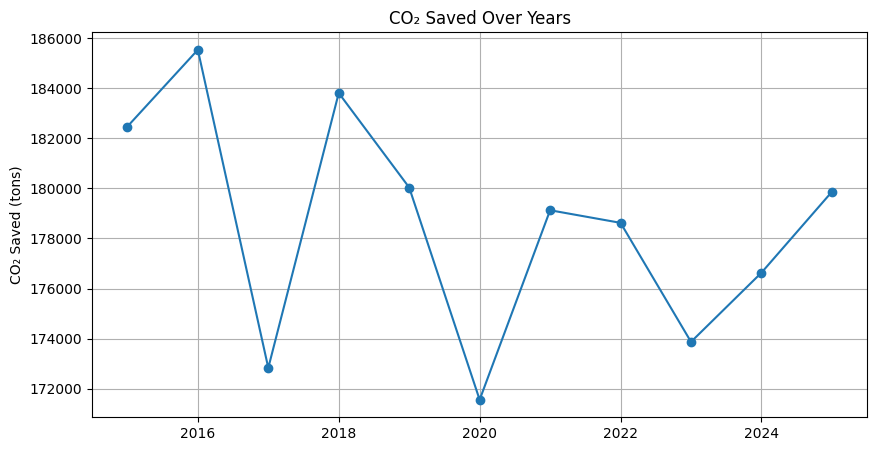

In [62]:
co2 = ev_data.groupby('Year')['CO2_Saved_tons'].sum()

plt.figure(figsize=(10,5))

plt.plot(
    co2.index,
    co2.values,
    marker='o'
)

plt.title('CO₂ Saved Over Years')
plt.ylabel('CO₂ Saved (tons)')

plt.grid(True)

plt.show()

### Key Observation

CO₂ savings increased over time, demonstrating the growing environmental impact of electric vehicle adoption and EV's contribution to sustainability.

## Feature Engineering

In [63]:
ev_data = ev_data.sort_values(
    by=['Year', 'Month']
)
# Quarterly delivery growth
ev_data['Growth_Percent'] = (
    ev_data['Estimated_Deliveries']
    .pct_change() * 100
)
# Previous quarter deliveries
ev_data['Lag_1'] = (
    ev_data['Estimated_Deliveries']
    .shift(1)
)
# 3-period moving average
ev_data['Rolling_Mean_3'] = (
    ev_data['Estimated_Deliveries']
    .rolling(window=3)
    .mean()
)
# Production minus deliveries
ev_data['Inventory_Gap'] = (
    ev_data['Production_Units']
    - ev_data['Estimated_Deliveries']
)
# Delivery efficiency
ev_data['Efficiency_Ratio'] = (
    ev_data['Estimated_Deliveries']
    / ev_data['Production_Units']
)
# Revenue per period
ev_data['Estimated_Revenue'] = (
    ev_data['Estimated_Deliveries']
    * ev_data['Avg_Price_USD']
)
# Quarter feature
ev_data['Quarter'] = (
    (ev_data['Month'] - 1) // 3
) + 1

In [64]:
ev_data = ev_data.dropna()
print(ev_data.shape)

(2638, 19)


In [65]:
for column in ['Region', 'Model', 'Source_Type']:
    encoder = LabelEncoder()
    ev_data[column] = encoder.fit_transform(ev_data[column])

In [66]:
model_features = [
    'Year',
    'Month',
    'Quarter',
    'Region',
    'Model',
    'Production_Units',
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km',
    'Charging_Stations',
    'Source_Type',
    'Growth_Percent',
    'Lag_1',
    'Rolling_Mean_3',
    'Inventory_Gap',
    'Efficiency_Ratio'
]
X = ev_data[model_features]
target = ev_data['Estimated_Deliveries']

## Chronological Train/Test Split

In [67]:
train_size = int(
    len(ev_data) * 0.80
)
X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]
y_train = target.iloc[:train_size]
y_test = target.iloc[train_size:]

### Why Chronological Split?

Since the data is time-based, the train-test split is performed in chronological order rather than randomly. This provides a more realistic evaluation of forecasting performance.

In [68]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Linear Regression

Baseline model without regularization.

In [69]:
linear = LinearRegression()
linear.fit(X_train,y_train)
linear_pred = linear.predict(X_test)

## Ridge Regression

Uses L2 regularization to reduce coefficient variance.

In [70]:
ridge = Ridge(alpha=1)
ridge.fit(X_train,y_train)
ridge_pred = ridge.predict(X_test)

## Lasso Regression

Uses L1 regularization and can perform feature selection by shrinking some coefficients to zero.

In [71]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train,y_train)
lasso_pred = lasso.predict(X_test)

## Evaluation Function

In [72]:
def evaluate(y_true,y_pred):
    mae = mean_absolute_error(y_true,y_pred)
    rmse = np.sqrt(
        mean_squared_error(y_true,y_pred)
    )
    r2 = r2_score(y_true,y_pred)
    return mae,rmse,r2

## Model Comparison

In [73]:
linear_metrics = evaluate(y_test, linear_pred)
ridge_metrics = evaluate(y_test, ridge_pred)
lasso_metrics = evaluate(y_test, lasso_pred)
results = pd.DataFrame({
    'Model': ['Linear', 'Ridge', 'Lasso'],
    'MAE': [
        linear_metrics[0],
        ridge_metrics[0],
        lasso_metrics[0]
    ],
    'RMSE': [
        linear_metrics[1],
        ridge_metrics[1],
        lasso_metrics[1]
    ],
    'R2': [
        linear_metrics[2],
        ridge_metrics[2],
        lasso_metrics[2]
    ]
})
results.sort_values(
    by='R2',
    ascending=False
)

,Model,MAE,RMSE,R2
0,Linear,5.762071e-12,6.904100e-12,1.0
1,Ridge,1.056026e-06,1.479666e-06,1.0
2,Lasso,1.509648e-03,1.869411e-03,1.0


## Cross Validation

In [76]:
from sklearn.model_selection import GridSearchCV
ridge_pipe = make_pipeline(
    StandardScaler(),
    Ridge()
)
param_grid = {
    'ridge__alpha': [0.01, 0.1, 1, 10, 100]
}
grid = GridSearchCV(
    ridge_pipe,
    param_grid,
    cv=5,
    scoring='r2'
)
grid.fit(X, target)
print("Best Alpha:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Alpha: {'ridge__alpha': 0.01}
Best CV Score: 0.9999999997829911


## Actual vs Predicted

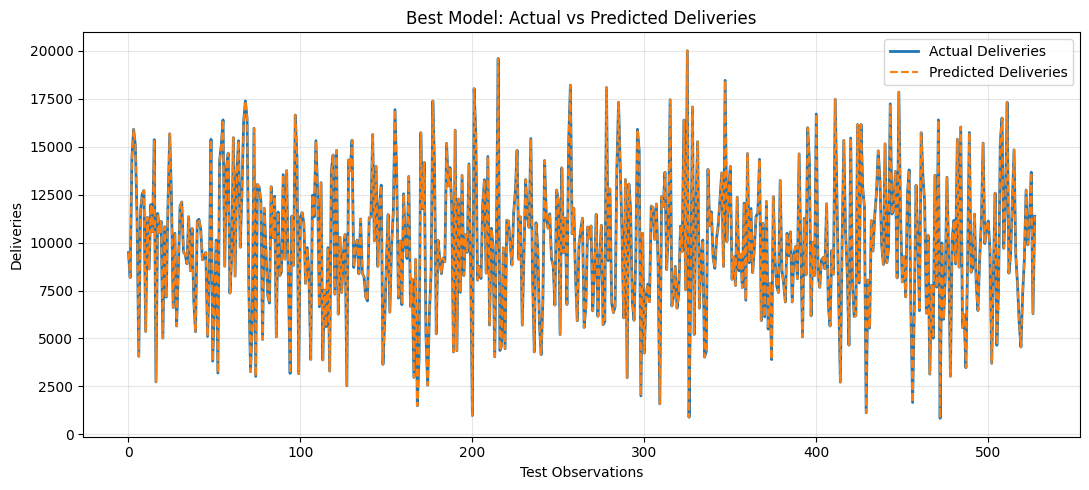

In [77]:
best_model = grid.best_estimator_
best_pred = best_model.predict(X_test)
plt.figure(figsize=(11, 5))
plt.plot(
    y_test.values,
    label='Actual Deliveries',
    linewidth=2
)
plt.plot(
    best_pred,
    label='Predicted Deliveries',
    linestyle='--'
)
plt.title('Best Model: Actual vs Predicted Deliveries')
plt.xlabel('Test Observations')
plt.ylabel('Deliveries')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Key Observation

The predicted values generally follow the trend of the actual deliveries, suggesting that the model captures the underlying delivery patterns reasonably well.

### Forecasting Insight

The forecasting model predicts future EV deliveries by leveraging historical delivery patterns through lag features and rolling statistics. The projected values suggest the expected delivery trajectory over the next four quarters based on historical trends and operational indicators.

# Conclusion

- EV deliveries increased steadily over time.
- Production growth closely aligned with delivery growth.
- Charging infrastructure showed a positive relationship with deliveries.
- Feature engineering improved the model's predictive capability.
- Linear Regression outperformed Ridge and Lasso on the test set.
- Historical and operational features were valuable for delivery prediction.

# Business Recommendations
1. Continue expanding charging infrastructure in high-growth regions.
2. Focus production on the highest-demand vehicle models.
3. Monitor battery technology improvements to increase driving range.
4. Use forecasting models for production planning and inventory management.